# 03 · Perceptron from Scratch: OR Gate, and why XOR fails
NumPy for the model · matplotlib for graphs · Runs on Google Colab

## Data: OR and XOR

In [1]:
import numpy as np

X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y_or  = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

print(" x1  x2 | OR  XOR")
for x, a, b in zip(X, y_or, y_xor):
    print(f"  {x[0]}   {x[1]} |  {a}   {b}")

rng = np.random.default_rng(42)

 x1  x2 | OR  XOR
  0   0 |  0   0
  0   1 |  1   1
  1   0 |  1   1
  1   1 |  1   0


## Functions

| Function | Formula |
|---|---|
| `step(s)` | $1$ if $s \ge \theta$ else $0$ |
| `forward_pass(x, w)` | $s = x \cdot w$, then $\hat{y} = \text{step}(s)$ |
| `compute_error(y, y_hat)` | $y - \hat{y}$ |
| `backward_pass(w, x, error, lr)` | $w + \eta \cdot \text{error} \cdot x$ |

In [2]:
THETA = 1.0                                   # threshold used by step()

def step(s):
    return 1 if s >= THETA else 0

def forward_pass(x, w):
    s = np.round(x @ w, 10) + 0.0             # weighted sum (rounding removes float noise and -0)
    return step(s), s

def compute_error(y, y_hat):
    return y - y_hat

def backward_pass(w, x, error, lr):
    return np.round(w + lr * error * x, 10) + 0.0


def train(X, y, w, lr, epochs):
    history = [w]                             # weights at the start and after every epoch (for plots)
    for epoch in range(1, epochs + 1):
        print(f"--- Epoch {epoch} ---")
        mistakes = 0
        for x, target in zip(X, y):
            y_hat, s = forward_pass(x, w)
            error = compute_error(target, y_hat)
            new_w = backward_pass(w, x, error, lr)

            calc = " + ".join(f"{xi:g}×{wi:g}" for xi, wi in zip(x, w))
            print(f"x={x} | s = {calc} = {s:g} ≥ {THETA:g}? -> {y_hat} | error = {target}-{y_hat} = {error:>2} | w = {new_w}")

            mistakes += int(error != 0)
            w = new_w
        print(f"mistakes: {mistakes}\n")
        history.append(w)
        if mistakes == 0:
            print(f"Learned in {epoch} epochs: w = {w}")
            return w, epoch, history
    print(f"Not learned in {epochs} epochs: w = {w}")
    return w, None, history


def test(X, y, w):
    for x, target in zip(X, y):
        y_hat, s = forward_pass(x, w)
        print(f"x={x} | s = {s:g} ≥ {THETA:g}? -> {y_hat} | target {target} {'✓' if y_hat == target else '✗'}")

## Plot helpers (matplotlib)

Decision boundary: $w_1 x_1 + w_2 x_2 = \theta$ (Part 1: $\theta$ = `THETA`, Part 2: $\theta = w_0$).
Green side ➜ output 1, red side ➜ output 0.

In [3]:
import io, contextlib, warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="No contour levels")   # a line can fall outside the view

grid = np.linspace(-0.5, 2.0, 300)
G1, G2 = np.meshgrid(grid, grid)

def train_quiet(X, y, w, lr, epochs):
    with contextlib.redirect_stdout(io.StringIO()):               # hide the training log
        return train(X, y, w, lr, epochs)

def draw_line(ax, w, color="k", style="-", alpha=1.0, shade=False):
    theta, w1, w2 = (w[0], w[1], w[2]) if len(w) == 3 else (THETA, w[0], w[1])
    S = w1 * G1 + w2 * G2 - theta
    if shade:
        ax.contourf(G1, G2, S, levels=[-1e9, 0, 1e9], colors=["#f6d5d5", "#d5efd5"])
    ax.contour(G1, G2, S, levels=[0], colors=[color], linestyles=style, alpha=alpha, linewidths=2)

def draw_points(ax, y, title=""):
    for (x1, x2), t in zip(X, y):
        ax.scatter(x1, x2, s=150, c="green" if t else "red", marker="o" if t else "X",
                   edgecolors="k", zorder=3)
    ax.set(xlim=(-0.5, 2.0), ylim=(-0.5, 2.0), xlabel="x1", ylabel="x2", title=title, aspect="equal")

def plot_history(history, y, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    draw_line(ax, history[-1], shade=True)
    colors = plt.cm.Blues(np.linspace(0.3, 1, len(history)))
    for i, w_e in enumerate(history):
        draw_line(ax, w_e, color=colors[i], style="--" if i == 0 else "-")
    draw_points(ax, y, f"{title}\n(dashed = start, light ➜ dark = epoch 1 ➜ {len(history) - 1})")
    plt.show()

---
# OR gate
## Part 1: fixed threshold θ = 1, learn $w_1, w_2$

In [4]:
THETA = 1.0
w = rng.uniform(-1, 1, size=2).round(2)       # random start
print("Start w =", w)
test(X, y_or, w)

Start w = [ 0.55 -0.12]
x=[0 0] | s = 0 ≥ 1? -> 0 | target 0 ✓
x=[0 1] | s = -0.12 ≥ 1? -> 0 | target 1 ✗
x=[1 0] | s = 0.55 ≥ 1? -> 0 | target 1 ✗
x=[1 1] | s = 0.43 ≥ 1? -> 0 | target 1 ✗


In [5]:
w1, _, hist1 = train(X, y_or, w, lr=0.1, epochs=30)

--- Epoch 1 ---
x=[0 0] | s = 0×0.55 + 0×-0.12 = 0 ≥ 1? -> 0 | error = 0-0 =  0 | w = [ 0.55 -0.12]
x=[0 1] | s = 0×0.55 + 1×-0.12 = -0.12 ≥ 1? -> 0 | error = 1-0 =  1 | w = [ 0.55 -0.02]
x=[1 0] | s = 1×0.55 + 0×-0.02 = 0.55 ≥ 1? -> 0 | error = 1-0 =  1 | w = [ 0.65 -0.02]
x=[1 1] | s = 1×0.65 + 1×-0.02 = 0.63 ≥ 1? -> 0 | error = 1-0 =  1 | w = [0.75 0.08]
mistakes: 3

--- Epoch 2 ---
x=[0 0] | s = 0×0.75 + 0×0.08 = 0 ≥ 1? -> 0 | error = 0-0 =  0 | w = [0.75 0.08]
x=[0 1] | s = 0×0.75 + 1×0.08 = 0.08 ≥ 1? -> 0 | error = 1-0 =  1 | w = [0.75 0.18]
x=[1 0] | s = 1×0.75 + 0×0.18 = 0.75 ≥ 1? -> 0 | error = 1-0 =  1 | w = [0.85 0.18]
x=[1 1] | s = 1×0.85 + 1×0.18 = 1.03 ≥ 1? -> 1 | error = 1-1 =  0 | w = [0.85 0.18]
mistakes: 2

--- Epoch 3 ---
x=[0 0] | s = 0×0.85 + 0×0.18 = 0 ≥ 1? -> 0 | error = 0-0 =  0 | w = [0.85 0.18]
x=[0 1] | s = 0×0.85 + 1×0.18 = 0.18 ≥ 1? -> 0 | error = 1-0 =  1 | w = [0.85 0.28]
x=[1 0] | s = 1×0.85 + 0×0.28 = 0.85 ≥ 1? -> 0 | error = 1-0 =  1 | w = [0.95 0.28]


x=[0 0] | s = 0 ≥ 1? -> 0 | target 0 ✓
x=[0 1] | s = 1.08 ≥ 1? -> 1 | target 1 ✓
x=[1 0] | s = 1.05 ≥ 1? -> 1 | target 1 ✓
x=[1 1] | s = 2.13 ≥ 1? -> 1 | target 1 ✓


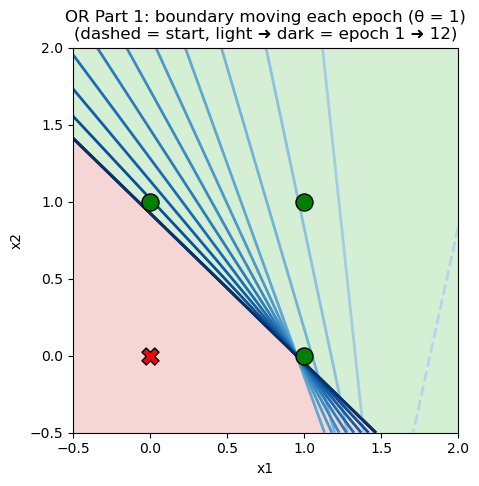

In [6]:
test(X, y_or, w1)
plot_history(hist1, y_or, "OR Part 1: boundary moving each epoch (θ = 1)")

## Part 2: threshold as $w_0$

Add $x_0 = -1$: $\;w_0 \cdot (-1) + w_1 x_1 + w_2 x_2 \ge 0 \iff w_1 x_1 + w_2 x_2 \ge w_0$, so $w_0$ is the threshold and `step` compares with 0.

In [7]:
THETA = 0.0                                   # threshold now lives in w0
X0 = np.hstack([-np.ones((len(X), 1), dtype=int), X])
print(X0)

w = rng.uniform(-1, 1, size=3).round(2)       # random start: w0 (threshold), w1, w2
print("\nStart w =", w)
test(X0, y_or, w)

[[-1  0  0]
 [-1  0  1]
 [-1  1  0]
 [-1  1  1]]

Start w = [ 0.72  0.39 -0.81]
x=[-1  0  0] | s = -0.72 ≥ 0? -> 0 | target 0 ✓
x=[-1  0  1] | s = -1.53 ≥ 0? -> 0 | target 1 ✗
x=[-1  1  0] | s = -0.33 ≥ 0? -> 0 | target 1 ✗
x=[-1  1  1] | s = -1.14 ≥ 0? -> 0 | target 1 ✗


In [8]:
w2, _, hist2 = train(X0, y_or, w, lr=0.1, epochs=30)

--- Epoch 1 ---
x=[-1  0  0] | s = -1×0.72 + 0×0.39 + 0×-0.81 = -0.72 ≥ 0? -> 0 | error = 0-0 =  0 | w = [ 0.72  0.39 -0.81]
x=[-1  0  1] | s = -1×0.72 + 0×0.39 + 1×-0.81 = -1.53 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.62  0.39 -0.71]
x=[-1  1  0] | s = -1×0.62 + 1×0.39 + 0×-0.71 = -0.23 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.52  0.49 -0.71]
x=[-1  1  1] | s = -1×0.52 + 1×0.49 + 1×-0.71 = -0.74 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.42  0.59 -0.61]
mistakes: 3

--- Epoch 2 ---
x=[-1  0  0] | s = -1×0.42 + 0×0.59 + 0×-0.61 = -0.42 ≥ 0? -> 0 | error = 0-0 =  0 | w = [ 0.42  0.59 -0.61]
x=[-1  0  1] | s = -1×0.42 + 0×0.59 + 1×-0.61 = -1.03 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.32  0.59 -0.51]
x=[-1  1  0] | s = -1×0.32 + 1×0.59 + 0×-0.51 = 0.27 ≥ 0? -> 1 | error = 1-1 =  0 | w = [ 0.32  0.59 -0.51]
x=[-1  1  1] | s = -1×0.32 + 1×0.59 + 1×-0.51 = -0.24 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.22  0.69 -0.41]
mistakes: 2

--- Epoch 3 ---
x=[-1  0  0] | s = -1×0.22 + 0×0.69 + 0×-0.41 = -0.22 ≥

x=[-1  0  0] | s = -0.02 ≥ 0? -> 0 | target 0 ✓
x=[-1  0  1] | s = 0.07 ≥ 0? -> 1 | target 1 ✓
x=[-1  1  0] | s = 0.67 ≥ 0? -> 1 | target 1 ✓
x=[-1  1  1] | s = 0.76 ≥ 0? -> 1 | target 1 ✓

Learned threshold w0 = 0.02


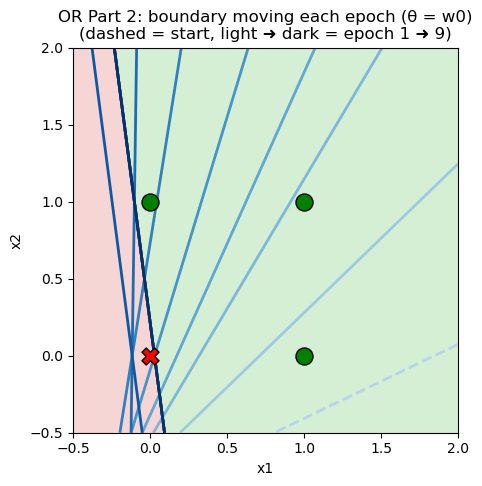

In [9]:
test(X0, y_or, w2)
print(f"\nLearned threshold w0 = {w2[0]:g}")
plot_history(hist2, y_or, "OR Part 2: boundary moving each epoch (θ = w0)")

## Experiment 1: learning rate (Part 2, 50 random starts each)

In [10]:
starts = [rng.uniform(-1, 1, size=3).round(2) for _ in range(50)]

print(f"{'lr':>8} | {'learned':>7} | {'avg epochs':>10} | final w from Part 2 start {w}")
print("-" * 78)
for lr in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]:
    epochs_needed = [train_quiet(X0, y_or, s0, lr, epochs=100)[1] for s0 in starts]
    w_final = train_quiet(X0, y_or, w, lr, epochs=100)[0]
    done = [e for e in epochs_needed if e is not None]
    avg = f"{np.mean(done):.1f}" if done else "-"
    print(f"{lr:>8} | {len(done):>3}/50  | {avg:>10} | {w_final}")

      lr | learned | avg epochs | final w from Part 2 start [ 0.72  0.39 -0.81]
------------------------------------------------------------------------------
  0.0001 |   3/50  |        1.0 | [ 0.69  0.41 -0.79]
   0.001 |   5/50  |       19.4 | [ 0.454  0.556 -0.61 ]
    0.01 |  38/50  |       51.2 | [0.01 0.66 0.01]
     0.1 |  50/50  |        9.5 | [0.02 0.69 0.09]
       1 |  50/50  |        4.0 | [0.72 1.39 1.19]
      10 |  50/50  |        4.1 | [ 0.72 10.39  9.19]
     100 |  50/50  |        4.1 | [  0.72 100.39  99.19]


### Graph: same start, different η

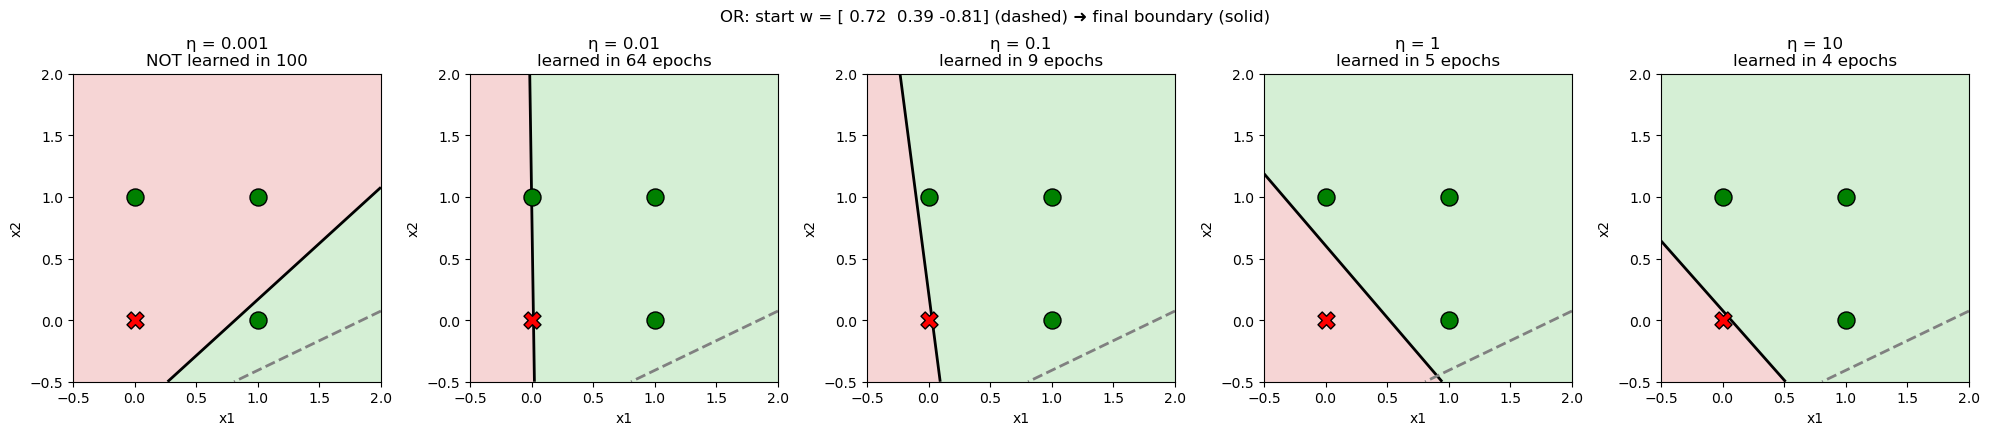

In [11]:
lrs = [0.001, 0.01, 0.1, 1, 10]
fig, axes = plt.subplots(1, len(lrs), figsize=(4 * len(lrs), 4.3))
for ax, lr in zip(axes, lrs):
    w_final, n, hist = train_quiet(X0, y_or, w, lr, epochs=100)
    draw_line(ax, w_final, shade=True)
    draw_line(ax, w, color="gray", style="--")
    result = f"learned in {n} epochs" if n else "NOT learned in 100"
    draw_points(ax, y_or, f"η = {lr}\n{result}")
fig.suptitle(f"OR: start w = {w} (dashed) ➜ final boundary (solid)")
plt.tight_layout()
plt.show()

### Graph: same η, different random starts

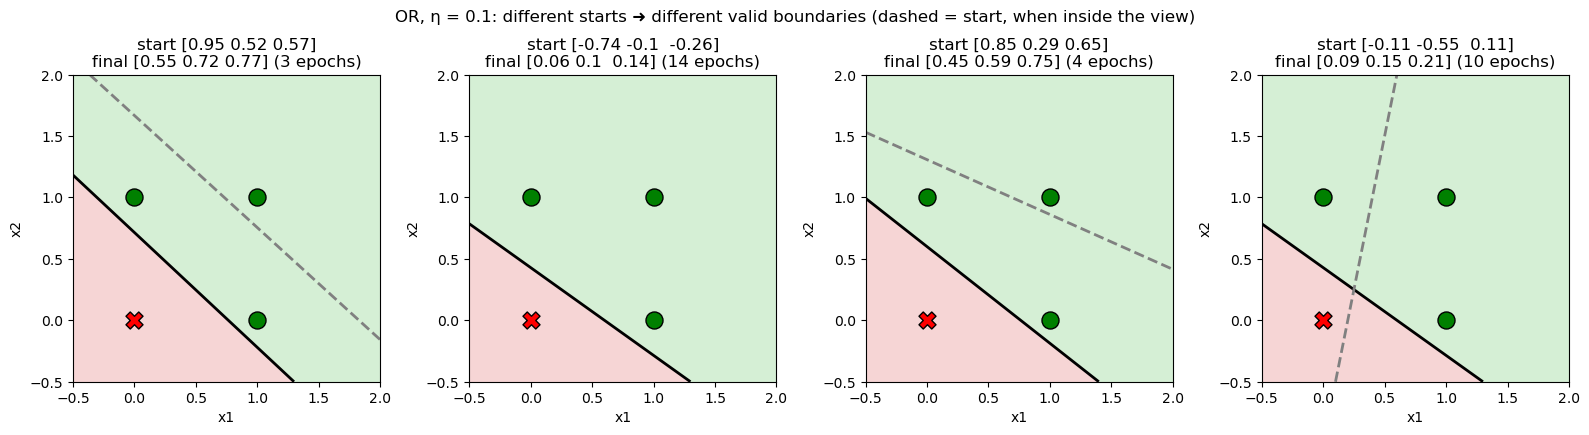

In [12]:
needs_training = [s0 for s0 in starts if train_quiet(X0, y_or, s0, 0.1, epochs=100)[1] > 1][:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, w_start in zip(axes, needs_training):
    w_final, n, hist = train_quiet(X0, y_or, w_start, 0.1, epochs=100)
    draw_line(ax, w_final, shade=True)
    draw_line(ax, w_start, color="gray", style="--")
    draw_points(ax, y_or, f"start {w_start}\nfinal {w_final} ({n} epochs)")
fig.suptitle("OR, η = 0.1: different starts ➜ different valid boundaries (dashed = start, when inside the view)")
plt.tight_layout()
plt.show()

### Graph: how η changes the path (boundary after every epoch)

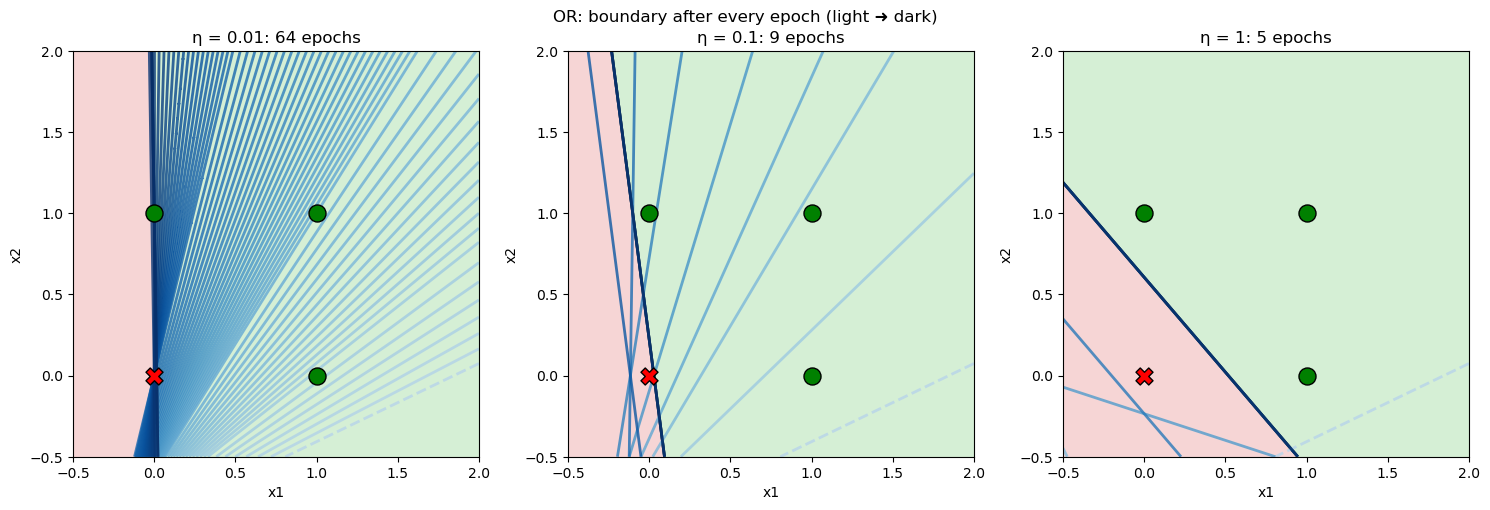

In [13]:
lrs = [0.01, 0.1, 1]
fig, axes = plt.subplots(1, len(lrs), figsize=(15, 5))
for ax, lr in zip(axes, lrs):
    w_final, n, hist = train_quiet(X0, y_or, w, lr, epochs=100)
    draw_line(ax, w_final, shade=True)
    colors = plt.cm.Blues(np.linspace(0.3, 1, len(hist)))
    for i, w_e in enumerate(hist):
        draw_line(ax, w_e, color=colors[i], style="--" if i == 0 else "-", alpha=0.8)
    draw_points(ax, y_or, f"η = {lr}: {len(hist) - 1} epochs")
fig.suptitle("OR: boundary after every epoch (light ➜ dark)")
plt.tight_layout()
plt.show()

---
# XOR gate: the perceptron cannot learn it
## 1. Train with the same code (Part 2 setup)

In [14]:
THETA = 0.0
w = rng.uniform(-1, 1, size=3).round(2)
print("Start w =", w)
_ = train(X0, y_xor, w, lr=0.1, epochs=6)     # only 6 epochs printed; it never ends

Start w = [ 0.34 -0.44  0.32]
--- Epoch 1 ---
x=[-1  0  0] | s = -1×0.34 + 0×-0.44 + 0×0.32 = -0.34 ≥ 0? -> 0 | error = 0-0 =  0 | w = [ 0.34 -0.44  0.32]
x=[-1  0  1] | s = -1×0.34 + 0×-0.44 + 1×0.32 = -0.02 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.24 -0.44  0.42]
x=[-1  1  0] | s = -1×0.24 + 1×-0.44 + 0×0.42 = -0.68 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.14 -0.34  0.42]
x=[-1  1  1] | s = -1×0.14 + 1×-0.34 + 1×0.42 = -0.06 ≥ 0? -> 0 | error = 0-0 =  0 | w = [ 0.14 -0.34  0.42]
mistakes: 2

--- Epoch 2 ---
x=[-1  0  0] | s = -1×0.14 + 0×-0.34 + 0×0.42 = -0.14 ≥ 0? -> 0 | error = 0-0 =  0 | w = [ 0.14 -0.34  0.42]
x=[-1  0  1] | s = -1×0.14 + 0×-0.34 + 1×0.42 = 0.28 ≥ 0? -> 1 | error = 1-1 =  0 | w = [ 0.14 -0.34  0.42]
x=[-1  1  0] | s = -1×0.14 + 1×-0.34 + 0×0.42 = -0.48 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.04 -0.24  0.42]
x=[-1  1  1] | s = -1×0.04 + 1×-0.24 + 1×0.42 = 0.14 ≥ 0? -> 1 | error = 0-1 = -1 | w = [ 0.14 -0.34  0.32]
mistakes: 2

--- Epoch 3 ---
x=[-1  0  0] | s = -1×0.14

## 2. Even 1000 epochs don't help: mistakes never reach 0

XOR learned? False


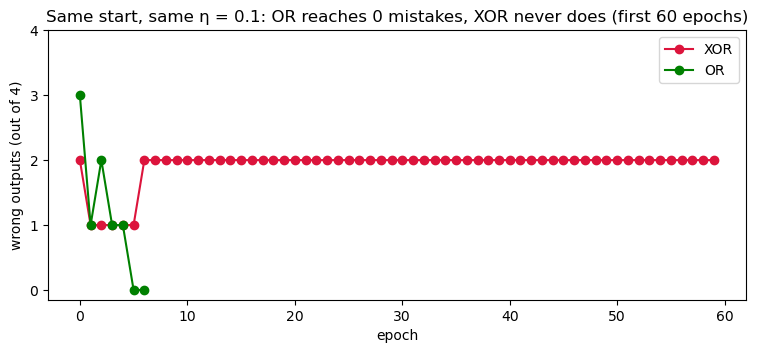

In [15]:
def count_mistakes(X, y, w):
    return sum(forward_pass(x, w)[0] != t for x, t in zip(X, y))

_, n, hist_xor = train_quiet(X0, y_xor, w, 0.1, epochs=1000)
_, _, hist_or = train_quiet(X0, y_or, w, 0.1, epochs=1000)
print("XOR learned?", n is not None)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot([count_mistakes(X0, y_xor, w_e) for w_e in hist_xor[:60]], "o-", color="crimson", label="XOR")
ax.plot([count_mistakes(X0, y_or,  w_e) for w_e in hist_or],       "o-", color="green",   label="OR")
ax.set(xlabel="epoch", ylabel="wrong outputs (out of 4)", yticks=range(5),
       title="Same start, same η = 0.1: OR reaches 0 mistakes, XOR never does (first 60 epochs)")
ax.legend()
plt.show()

## 3. The boundary keeps jumping around, and no position is correct

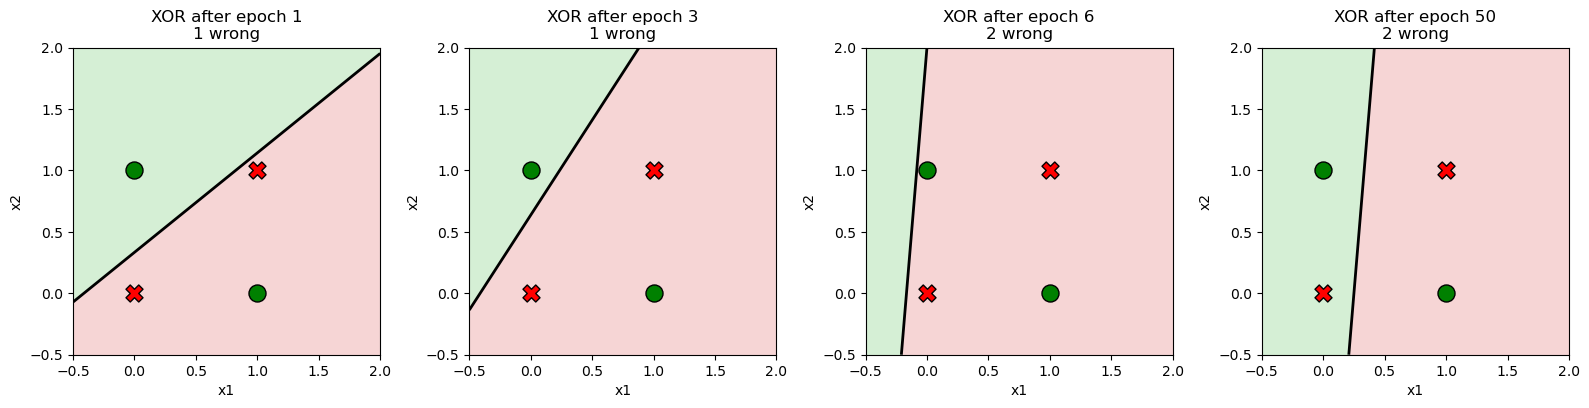

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, e in zip(axes, [1, 3, 6, 50]):
    draw_line(ax, hist_xor[e], shade=True)
    draw_points(ax, y_xor, f"XOR after epoch {e}\n{count_mistakes(X0, y_xor, hist_xor[e])} wrong")
plt.tight_layout()
plt.show()

## 4. No learning rate and no random start works

In [17]:
print(f"{'lr':>8} | {'OR learned':>10} | {'XOR learned':>11}")
print("-" * 36)
for lr in [0.001, 0.01, 0.1, 1, 10]:
    or_ok  = sum(train_quiet(X0, y_or,  s0, lr, epochs=200)[1] is not None for s0 in starts)
    xor_ok = sum(train_quiet(X0, y_xor, s0, lr, epochs=200)[1] is not None for s0 in starts)
    print(f"{lr:>8} | {or_ok:>6}/50   | {xor_ok:>7}/50")

      lr | OR learned | XOR learned
------------------------------------
   0.001 |      7/50   |       0/50
    0.01 |     50/50   |       0/50
     0.1 |     50/50   |       0/50
       1 |     50/50   |       0/50
      10 |     50/50   |       0/50


## 5. Brute force: try every line on a grid

Check every $(w_0, w_1, w_2)$ from −2 to 2 in steps of 0.05 (≈ 530,000 lines) and keep the best accuracy.

In [18]:
vals = np.round(np.arange(-2, 2.0001, 0.05), 10)
W = np.array(np.meshgrid(vals, vals, vals)).reshape(3, -1).T      # every [w0, w1, w2]
S = X0 @ W.T                                                      # s for 4 inputs × all lines
preds = (np.round(S, 10) >= 0).astype(int)

print(f"Lines tried: {len(W):,}\n")
for name, target in [("AND", np.array([0, 0, 0, 1])), ("OR", y_or), ("XOR", y_xor)]:
    correct = (preds == target[:, None]).sum(axis=0)
    print(f"{name:>3}: best = {correct.max()}/4 correct | lines that get 4/4: {(correct == 4).sum():,}")

Lines tried: 531,441

AND: best = 4/4 correct | lines that get 4/4: 10,660
 OR: best = 4/4 correct | lines that get 4/4: 22,140
XOR: best = 3/4 correct | lines that get 4/4: 0


## 6. Why: the 4 conditions contradict each other

| Input | XOR | Condition ($w_1 x_1 + w_2 x_2 \ge \theta$ ?) |
|---|:-:|---|
| (0,0) | 0 | $0 < \theta$ |
| (0,1) | 1 | $w_2 \ge \theta$ |
| (1,0) | 1 | $w_1 \ge \theta$ |
| (1,1) | 0 | $w_1 + w_2 < \theta$ |

Adding rows 2 and 3: $w_1 + w_2 \ge 2\theta > \theta$ (because $\theta > 0$), which breaks row 4. **No single line can do it.**

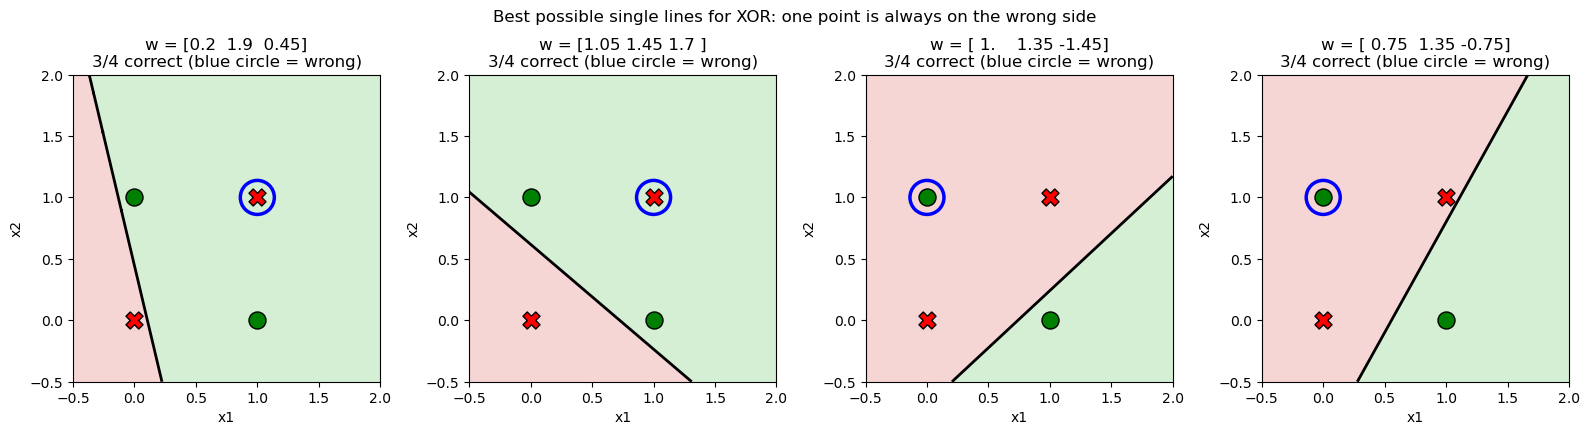

In [19]:
best = W[(preds == y_xor[:, None]).sum(axis=0) == 3]
picks = best[rng.choice(len(best), 4, replace=False)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, w_b in zip(axes, picks):
    draw_line(ax, w_b, shade=True)
    draw_points(ax, y_xor)
    wrong = [x for x, t in zip(X, y_xor) if forward_pass(np.r_[-1, x], w_b)[0] != t]
    for x1, x2 in wrong:
        ax.scatter(x1, x2, s=600, facecolors="none", edgecolors="blue", linewidths=2.5, zorder=4)
    ax.set_title(f"w = {w_b}\n3/4 correct (blue circle = wrong)")
fig.suptitle("Best possible single lines for XOR: one point is always on the wrong side")
plt.tight_layout()
plt.show()

**XOR needs two lines**, which means more than one perceptron connected in layers ➜ next folder: `02_Neural_Networks`.